# PART3 - QC FRAMEWORK 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
df = pd.read_csv("C:/Users/dlmat/Documents/Projects/Differencial_Bio/data/L_rhamnosus_fermentation_data.csv")

In [3]:
df

,ID,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,Meat extract,CH3COONa: Sodium acetate,Tween 80 [ml/L],Maximal OD,Plate Number,Plate Row,Plate Column,Plate ID
0,1_10_0,1,10,10,2,0.1,5,1.0,0,2.5,0.0,0.990000,1,B,2,r3-c1-idx1-96 Well Microplate
1,1_10_1,1,10,10,2,0.1,5,1.0,0,2.5,0.0,1.240000,1,B,2,r3-c1-idx1-96 Well Microplate
2,1_11_0,1,5,10,1,0.1,5,1.0,0,2.5,2.0,1.060000,1,C,2,r3-c1-idx1-96 Well Microplate
3,1_11_1,1,5,10,1,0.1,5,1.0,0,2.5,2.0,0.930000,1,C,2,r3-c1-idx1-96 Well Microplate
4,1_12_0,1,0,0,1,0.1,20,0.0,0,2.5,0.0,0.604807,1,D,2,r3-c1-idx1-96 Well Microplate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,16_14_1,4,0,10,10,1.0,40,0.0,20,10.0,0.5,1.100000,16,F,2,r4-c2-idx6-96 Well Microplate
996,16_15_0,4,20,50,10,2.0,0,0.0,10,10.0,0.5,1.010000,16,G,2,r4-c2-idx6-96 Well Microplate
997,16_15_1,4,20,50,10,2.0,0,0.0,10,10.0,0.5,1.120000,16,G,2,r4-c2-idx6-96 Well Microplate
998,16_16_0,4,40,50,0,1.0,0,1.0,5,10.0,0.5,0.820000,16,H,2,r4-c2-idx6-96 Well Microplate


# Step 1 - Basic Sanity

## 1.1 Missing Values
RESULT : No missing values from any column

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              1000 non-null   object 
 1   K2HPO4: Dipotassium phosphate   1000 non-null   int64  
 2   Peptone (Soy)                   1000 non-null   int64  
 3   Glucose                         1000 non-null   int64  
 4   Ammonium citrate                1000 non-null   int64  
 5   MgSO4: Magnesium sulfate        1000 non-null   float64
 6   Yeast extract                   1000 non-null   int64  
 7   MnSO4 · H2O: Manganese sulfate  1000 non-null   float64
 8   Meat extract                    1000 non-null   int64  
 9   CH3COONa: Sodium acetate        1000 non-null   float64
 10  Tween 80 [ml/L]                 1000 non-null   float64
 11  Maximal OD                      1000 non-null   float64
 12  Plate Number                    100

## 1.2 Duplicate Rows
RESULT : no duplicate rows. 

In [5]:
## Check for duplicates
df[df.duplicated()]

,ID,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,Meat extract,CH3COONa: Sodium acetate,Tween 80 [ml/L],Maximal OD,Plate Number,Plate Row,Plate Column,Plate ID


## 1.3 Global Distribution Summary &  Impossible Values
RESULT:
* There are no negative numbers which is a good sign.
* The minimum and maximum OD is 0 and 1.5 respectively. If I knew what device was used I could state if it was in possible limits, but the numbers dont seem too crazy.
* The histogram shows binomial curve, this is interesting. Both the histogram and the boxplot show skewness to the right, why? There seems two maxima growth points, some conbinations are good and others are great at growing. 
* there are many values at 1.3 this could be a potencial celing/saturation

In [4]:
df.describe()

,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,Meat extract,CH3COONa: Sodium acetate,Tween 80 [ml/L],Maximal OD,Plate Number,Plate Column
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.789000,13.120000,22.450000,3.182000,0.67540,13.710000,0.58160,12.125000,5.857500,1.340500,0.887722,10.963000,5.984000
std,1.172115,12.922174,18.526757,3.336466,0.76315,13.323416,0.73138,12.408196,4.776899,1.343918,0.430213,4.316511,3.167614
min,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.000000,5.000000,10.000000,1.000000,0.10000,5.000000,0.10000,5.000000,2.500000,0.500000,0.530000,10.000000,3.000000
50%,2.000000,10.000000,20.000000,2.000000,0.20000,10.000000,0.20000,10.000000,5.000000,1.000000,0.980000,12.000000,6.000000
75%,4.000000,20.000000,40.000000,4.000000,1.00000,20.000000,1.00000,20.000000,10.000000,2.000000,1.280000,14.000000,9.000000
max,4.000000,40.000000,50.000000,10.000000,2.00000,40.000000,2.00000,40.000000,15.000000,4.000000,1.500000,16.000000,11.000000


## 1.4 Feature Enigneering & Saving info.
*  Created column that flags if there are any missing OD values.
*  Creates column that checks if there are any OD values less than 0.
*  Saves distribution summary.
*  Creates and saves histogram and boxplot of OD distributuion.

In [7]:
def check_OD(df, output_path):
    """
    Created column that flags if there are any missing OD values.
    Creates column that checks if there are any OD values less than 0. 
    """
    df["OD_missing"] = df['Maximal OD'].isna()
    df["OD_outofrange"] = df['Maximal OD'] < 0
    df.to_csv(output_path+"/sanity_check.csv")

def distributuion_summary(df, output_path):
    """
    Saves distribution summary.
    """
    ds = df.describe()
    ds.to_csv(output_path+"/distributuion_summary.csv")

def OD_figures(df, output_path):
    """
    Creates and saves histogram and boxplot. 
    """
    fig, (ax_hist, ax_box) = plt.subplots(
        2, 1,
        sharex=True,
        gridspec_kw={"height_ratios": (4, 1)},
        figsize=(8, 6)
    )
    
    # Histogram
    sns.histplot(
        df["Maximal OD"],
        kde=True,
        bins=30,
        color="skyblue",
        edgecolor="blue",
        alpha=0.7,
        ax=ax_hist
    )
    
    mean = df["Maximal OD"].mean()
    median = df["Maximal OD"].median()
    
    ax_hist.axvline(mean, color='red', linestyle='--', label=f"Mean: {mean:.2f}")
    ax_hist.axvline(median, color='green', linestyle='--', label=f"Median: {median:.2f}")
    ax_hist.set_ylabel("Frequency")
    ax_hist.legend()
    
    # Horizontal boxplot
    sns.boxplot(
        x=df["Maximal OD"],
        ax=ax_box,
        color="lightgray"
    )
    
    ax_box.set_xlabel("Maximal OD")
    ax_box.set_yticks([])
    
    plt.tight_layout()
    plt.savefig(output_path+'/OD600_spread.png')

    

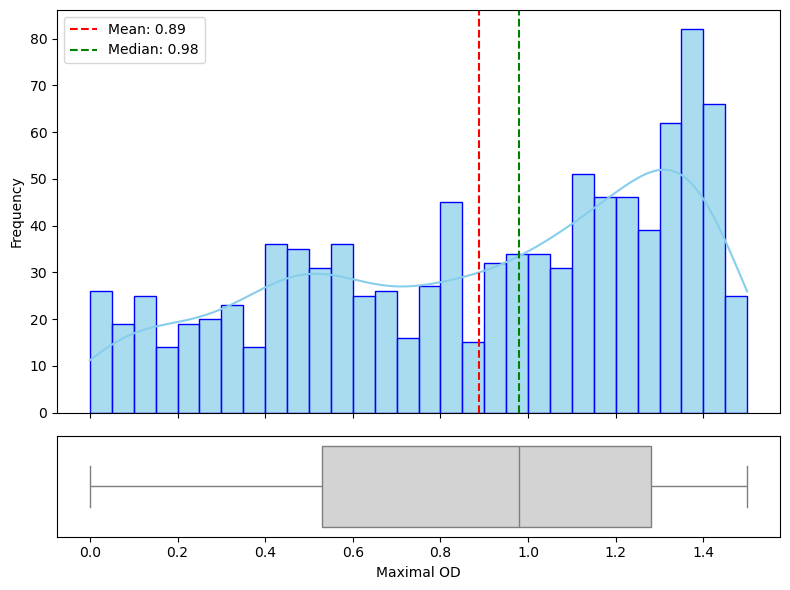

In [8]:
output_path = "C:/Users/dlmat/Documents/Projects/Differencial_Bio/data/EDA_OD600"
check_OD(df,output_path)
distributuion_summary(df,output_path)
OD_figures(df,output_path)


## 1.5 Check for Blanks 
Zero growth is defined as OD =< 0.1 to account for baseline absorbance.
no control was provided. 
why are blanks important? cause they identify weak media region or innoculation issue. 

* 4.6% of wells have zero growth. 
* plate 13, 14 and 10 are the worst at growth. this might mean they have a weak media for growth, or inoculation issue. 
* 16 is the best for growth
* nothing is discualifying yet.
* there are no media blanks
* 

continuing as if there are no blanks.

In [45]:
percent = df[df['Maximal OD']<=0.1].shape[0]*100/df.shape[0]
print(percent)

4.6


In [46]:
threshold = 0.1

plate_summary = (
    df
    .groupby("Plate Number")
    .apply(lambda x: (x["Maximal OD"] <= threshold).mean() * 100)
)
plate_summary

C:\Users\dlmat\AppData\Local\Temp\ipykernel_16440\99888349.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["Maximal OD"] <= threshold).mean() * 100)


Plate Number
1      2.158273
10     4.964539
11     2.255639
12     2.142857
13    10.666667
14     6.944444
15     2.797203
16     0.000000
dtype: float64

In [47]:
# if there are media blanks then all media would be 0. 
media_cols = [
"Peptone (Soy)",
"Glucose",
"Ammonium citrate",
"MgSO4: Magnesium sulfate",
"Yeast extract",
"MnSO4 · H2O: Manganese sulfate",
"Meat extract",
"CH3COONa: Sodium acetate",
"Tween 80 [ml/L]"
]

df[df[media_cols].sum(axis=1) == 0]


,ID,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,Meat extract,CH3COONa: Sodium acetate,Tween 80 [ml/L],Maximal OD,Plate Number,Plate Row,Plate Column,Plate ID,OD_missing,OD_outofrange


# Step 2 - Plate-Level QC

Plan of Action: 

A. Per-Plate Summary

    - Group by Plate Number.
    - Compute per plate:
        * Median OD
        * IQR
        * % zero growth (perhaps)
        * % outliers (perhaps)
    - Plot:
        * Boxplot of OD per plate
    - Flag:
        * Plates whose median deviates strongly from others.

B) Spatial Heatmap

    - For each plate:
    - Pivot:
        * Rows = Plate Row
        * Columns = Plate Column
        * Values = Maximal OD
    - Plot heatmap.  
    - looking for:
        * Edge effects (outer wells lower/higher)
        * Row gradient
        * Column gradient
        * Corner anomalies
        * clustering

C) Edge Effect Check
        
    - Define edge wells:
        * Row = A or H (if 96-well)
        * Column = 1 or 12
        
    - Compare:
        * Median OD (edge) vs (interior)
        * If difference > ~0.1 OD or > 0.5 SD: Flag as possible evaporation effect.

**My questions and answers from data.**
- What label identifies the plates? Plate Number or plate ID? Platte number, each plate number represents and eperimental batch.
- how many plates are there? There are 8 plates.
- what is the dimention of these plates? Layout is 8×11 (column 12 unused).
- how many wells do each plate have? they differ, the plates vary from 139-150 and one of 10
- are there replicates? yes there are replicates. 407 sample pairs are replicates 407, where as 186 samples are not
- do the replicates concur with eachother? some do others dont. some replicates have very similar OD values and thus have a small cv. others have 'binary disagreement'. this is not from a biological source it can be derived from setup, like pipetting error in one replicate, Inoculation inconsistency, Edge evaporation, Local contamination, Misdispensed media.

**Findings**
- some [plate numbers, row, column] repetitions exsist. There are technical duplicates for many wells, which could be replicate measurements or repeated runs. Some wells are only measured once. 
- While median replicate CV was 7.2% among the 8 plates, approximately 16% of replicated wells exhibited high disagreement (CV > 0.5), ( one replicate showing growth and the other near-zero signal). 66 wells with CV > 0.5. 
- lets see why these replicates differ, are these high cv raplicates Randomly scattered? then it is random noise. Spatially clustered? then it is plate level bias. Concentrated in specific plates? then it is batch-level failure. 
- which plate has the highest cv? 13 and 11. 
- how what do we do with these replicates that disagree?
- how can we trust the ones that do not have replicates?

## 2.1 Understanding plate layout

### Measurment count

In [47]:
# how many mesurements were taken per plate, expected 96. 
print(df["Plate Number"].nunique())
df['Plate Number'].value_counts()

8


Plate Number
13    150
14    144
15    143
10    141
12    140
1     139
11    133
16     10
Name: count, dtype: int64

In [48]:
# What do the plat ID look like? does it parallel the plate number?
print(df["Plate ID"].nunique())
df['Plate ID'].value_counts()

7


Plate ID
r3-c1-idx1-96 Well Microplate     272
r1-c2-idx3-96 Well Microplate     150
r2-c2-idx4-96 Well Microplate     144
r3-c2-idx5-96 Well Microplate     143
r4-c3-idx10-96 Well Microplate    141
r4-c1-idx2-96 Well Microplate     140
r4-c2-idx6-96 Well Microplate      10
Name: count, dtype: int64

### rows and columns

In [49]:
# how many unique row values are there in total?
df["Plate Row"].unique()

array(['B', 'C', 'D', 'E', 'G', 'A', 'F', 'H'], dtype=object)

In [50]:
# how many unique columns values are there in total?
df["Plate Column"].unique()

array([ 2,  3,  1,  4,  5,  6,  7,  8,  9, 10, 11])

## 2.2 Replicates

In [51]:
# check if the duplicates are doubled or more 
df.groupby(["Plate Number","Plate Row","Plate Column"]).size().value_counts()
# There are technical duplicates for many cells! 

2    407
1    186
Name: count, dtype: int64

In [7]:
# making df grouped by plate row and column. 
dup_check = (
    df
    .groupby(["Plate Number","Plate Row","Plate Column"])
    .nunique()
)

In [10]:
# df that contains the plate, row and colum of all samples, replicates have a coutn of 2 where, single have a count of 1
replicate_counts = (
    df
    .groupby(["Plate Number","Plate Row","Plate Column"])
    .size()
    .reset_index(name="count")
)

replicate_counts[replicate_counts["count"] == 2].head()


,Plate Number,Plate Row,Plate Column,count
2,1,A,3,2
3,1,A,4,2
5,1,A,6,2
6,1,A,7,2
7,1,A,8,2


In [16]:
# Lets CHECK if the same location, column and row combination also have the same media recipie. 
example = replicate_counts[replicate_counts["count"] == 2].iloc[3]

plate = example["Plate Number"]
row = example["Plate Row"]
col = example["Plate Column"]

df[
    (df["Plate Number"] == plate) &
    (df["Plate Row"] == row) &
    (df["Plate Column"] == col)
]


,ID,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,Meat extract,CH3COONa: Sodium acetate,Tween 80 [ml/L],Maximal OD,Plate Number,Plate Row,Plate Column,Plate ID,OD_missing,OD_outofrange
62,1_49_0,1,40,40,4,1.0,20,0.2,5,2.5,4.0,1.38,1,A,7,r3-c1-idx1-96 Well Microplate,False,False
63,1_49_1,1,40,40,4,1.0,20,0.2,5,2.5,4.0,1.47,1,A,7,r3-c1-idx1-96 Well Microplate,False,False


In [17]:
# Check if the combination of components is the same for all the presumed replicates, to confirm replicates have idendical conditions.
df.groupby(
    ["Plate Number","Plate Row","Plate Column"]
)[
    [
        "K2HPO4: Dipotassium phosphate",
        "Peptone (Soy)",
        "Glucose",
        "Ammonium citrate",
        "MgSO4: Magnesium sulfate",
        "Yeast extract",
        "MnSO4 · H2O: Manganese sulfate",
        "Meat extract",
        "CH3COONa: Sodium acetate",
        "Tween 80 [ml/L]"
    ]
].nunique().max()


K2HPO4: Dipotassium phosphate     1
Peptone (Soy)                     1
Glucose                           1
Ammonium citrate                  1
MgSO4: Magnesium sulfate          1
Yeast extract                     1
MnSO4 · H2O: Manganese sulfate    1
Meat extract                      1
CH3COONa: Sodium acetate          1
Tween 80 [ml/L]                   1
dtype: int64

### Do the replicates agree? 

In [18]:
# make df contiaing the replicates mean OD, std and cv.
rep_stats = (
    df
    .groupby(["Plate Number","Plate Row","Plate Column"])
    ["Maximal OD"]
    .agg(["count","mean","std"])
    .reset_index()
)

rep_stats = rep_stats[rep_stats["count"] == 2]
rep_stats["cv"] = rep_stats["std"] / rep_stats["mean"]


In [20]:
# show median cv and max cv. 
print(rep_stats["cv"].median(),
rep_stats["cv"].max())


0.0720971620033344 1.4142135623730951


a median of 7% is good. it means solid technical precision, pipetting is stable, oD reading is stable, most measurements are trustworthy, through our all of the replicates on all the wells. 

the max cv of 141% is too big. it likely corresponds to near zero growth and noise dominating signal

for a given replicate, if the mean is quite small and the cv is large that is ok, but if the mean is large and the cv is large it means there is a big difference between the replicate's OD. That is binary disagreement. one measurement suggests song growth and the other suggests failure. 


In [53]:
# lets check the OD of the well with the highest CV
rep_stats.sort_values("cv", ascending=False).head(20)


,Plate Number,Plate Row,Plate Column,count,mean,std,cv,high_cv
279,12,D,5,2,0.075000,0.106066,1.414214,True
155,10,H,6,2,0.055469,0.078445,1.414214,True
320,12,H,4,2,0.201553,0.285038,1.414214,True
394,13,G,1,2,0.093578,0.132340,1.414214,True
146,10,G,7,2,0.081362,0.115064,1.414214,True
23,1,C,7,2,0.207918,0.294040,1.414214,True
366,13,D,6,2,0.145515,0.204333,1.404211,True
378,13,E,7,2,0.734546,1.025947,1.396710,True
377,13,E,6,2,0.715308,0.996584,1.393223,True
174,11,B,3,2,0.570926,0.793269,1.389443,True


In [54]:
# example of disagreeing replicates (high cv)
df[
    (df["Plate Number"] == 12) &
    (df["Plate Row"] == "D") &
    (df["Plate Column"] == 5)
]


,ID,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,Meat extract,CH3COONa: Sodium acetate,Tween 80 [ml/L],Maximal OD,Plate Number,Plate Row,Plate Column,Plate ID
456,12_36_0,2,5,10,0,2.0,0,0.0,0,15.0,0.5,0.00,12,D,5,r4-c1-idx2-96 Well Microplate
457,12_36_1,2,5,10,0,2.0,0,0.0,0,15.0,0.5,0.15,12,D,5,r4-c1-idx2-96 Well Microplate


In [55]:
#how many wells have a large disagremetn (cv>0.5)
(rep_stats["cv"] > 0.5).mean()



0.16216216216216217

This is a moderate issue. ~16.2% of replicate wells that a disagreement larger than cv 0.5, ~84% of replicated wells are consistent

16% show strong replicate disagreement

now we have to ask ourselves some question about why theses errors occures , bellow you will see some questions to answer. 

In [56]:
# how many wells are in the ~16.2%? 
print((rep_stats["cv"] > 0.5).sum(),
(rep_stats["cv"] > 0.5).mean())


66 0.16216216216216217


66 wells.

**Questions**
* are these wells randomly scattered?
* appear in clusters?
* are on specific plates?
  - some plates have higher cv than otheres like 11 and 13. 
* random noise, plate-level bias, batch-level failure?


why do replicated differ?
* Conditions are near growth threshold/ borderline
* Small inoculum differences flip outcome


### what plates have the highest disagreing replicates? 

In [57]:
# make column that flags which wells have high cv
rep_stats["high_cv"] = rep_stats["cv"] > 0.5
# group by plate, get all the rows with high_cv and find their mean. 
rep_stats.groupby("Plate Number")["high_cv"].mean()

Plate Number
1     0.116667
10    0.152542
11    0.215686
12    0.163636
13    0.258065
14    0.135593
15    0.103448
16    0.000000
Name: high_cv, dtype: float64

Some plates have higher cv than others. 

<Axes: xlabel='Plate Number', ylabel='CV score'>

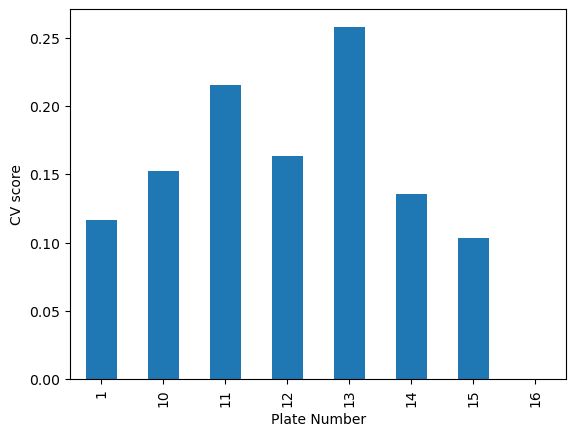

In [129]:
rep_stats.groupby("Plate Number")["high_cv"].mean().plot.bar(ylabel = "CV score", title = "Replicate Dissageement" )


plate 13 and 11 stadout. That suggests plate-level *heterogeneity*

why are some plates noisier? these might be some reasons:

- Slightly inconsistent inoculum on certain plates
- Local environmental variation (humidity, incubation position)
- Slight dispensing variability on specific batch
- Biological threshold effects more common in certain media subsets

In [26]:
# lets look at plate 13
df[df['Plate Number'] == 13]

,ID,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,Meat extract,CH3COONa: Sodium acetate,Tween 80 [ml/L],Maximal OD,Plate Number,Plate Row,Plate Column,Plate ID,OD_missing,OD_outofrange
553,13_10_0,4,5,10,10,0.2,40,0.1,40,2.5,0.0,0.97,13,B,2,r1-c2-idx3-96 Well Microplate,False,False
554,13_11_0,4,20,40,4,0.2,40,0.1,5,2.5,4.0,1.43,13,C,2,r1-c2-idx3-96 Well Microplate,False,False
555,13_11_1,4,20,40,4,0.2,40,0.1,5,2.5,4.0,1.44,13,C,2,r1-c2-idx3-96 Well Microplate,False,False
556,13_12_0,4,20,50,0,0.2,10,0.2,0,2.5,0.5,1.15,13,D,2,r1-c2-idx3-96 Well Microplate,False,False
557,13_12_1,4,20,50,0,0.2,10,0.2,0,2.5,0.5,0.55,13,D,2,r1-c2-idx3-96 Well Microplate,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
698,13_88_1,4,5,0,2,0.1,0,0.1,5,5.0,4.0,0.26,13,H,11,r1-c2-idx3-96 Well Microplate,False,False
699,13_8_0,4,20,20,4,0.1,10,1.0,20,2.5,2.0,1.42,13,H,1,r1-c2-idx3-96 Well Microplate,False,False
700,13_8_1,4,20,20,4,0.1,10,1.0,20,2.5,2.0,1.41,13,H,1,r1-c2-idx3-96 Well Microplate,False,False
701,13_9_0,4,10,40,10,0.2,0,0.1,20,2.5,0.0,1.21,13,A,2,r1-c2-idx3-96 Well Microplate,False,False


In [28]:
plate13 = rep_stats[rep_stats["Plate Number"] == 13].copy()
plate13["high_cv"] = (plate13["cv"] > 0.5).astype(int)

In [29]:
heat = plate13.pivot(
    index="Plate Row",
    columns="Plate Column",
    values="high_cv"
)

In [30]:
heat = heat.astype(float)

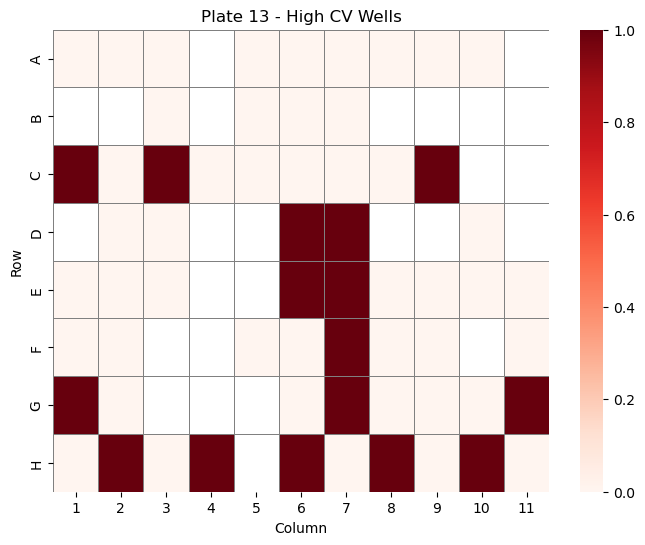

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    heat,
    cmap="Reds",
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Plate 13 - High CV Wells")
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()


plate 13 observation:
- row H clustering, edge effect? (evaporation, temp diff, condensation, volume diff? 
- Columns 6-7 Cluster

Columns 6–7 Cluster
 - Column 6 (D, E, H)
 - Column 7 (D, E, F, G)
 - dispensing effect? Liquid handler channel inconsistency? 

Not biological caused, this is spatial technical variability

## 2.3 Heatmaps!

In [29]:
well_stats

,Plate Number,Plate Row,Plate Column,n,mean,std,cv,has_reps,vmin,vmax,binary_disagreement,high_cv
0,1,A,1,1,1.020,NaN,NaN,False,1.02,1.02,False,False
1,1,A,2,1,1.270,NaN,NaN,False,1.27,1.27,False,False
2,1,A,3,2,0.685,0.021213,0.030968,True,0.67,0.70,False,False
3,1,A,4,2,1.095,0.190919,0.174355,True,0.96,1.23,False,False
4,1,A,5,1,1.220,NaN,NaN,False,1.22,1.22,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
588,16,D,2,2,0.495,0.077782,0.157135,True,0.44,0.55,False,False
589,16,E,2,1,1.440,NaN,NaN,False,1.44,1.44,False,False
590,16,F,2,1,1.100,NaN,NaN,False,1.10,1.10,False,False
591,16,G,2,2,1.065,0.077782,0.073035,True,1.01,1.12,False,False


In [25]:
import numpy as np
import pandas as pd

# check dtypes
df["Plate Column"] = df["Plate Column"].astype(int)
df["Plate Row"] = df["Plate Row"].astype(str)

# make df with nessesary info for the wells.
well_stats = (
    df.groupby(["Plate Number", "Plate Row", "Plate Column"])["Maximal OD"]
      .agg(n="count", mean="mean", std="std")
      .reset_index()
)

# CV only matters when n>=2 and mean>0
well_stats["cv"] = well_stats["std"] / well_stats["mean"]

# flag replicates
well_stats["has_reps"] = well_stats["n"] >= 2

# make df containing each well and their max and min OD values
minmax = (
    df.groupby(["Plate Number","Plate Row","Plate Column"])["Maximal OD"]
      .agg(vmin="min", vmax="max")
      .reset_index()
)

# merge dfs
well_stats = well_stats.merge(minmax, on=["Plate Number","Plate Row","Plate Column"], how="left")

# flag binary disagreement and high cv
well_stats["binary_disagreement"] = (well_stats["vmin"] <= 0.1) & (well_stats["vmax"] > 0.3) & well_stats["has_reps"]
well_stats["high_cv"] = (well_stats["cv"] > 0.5) & well_stats["has_reps"]


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

ROW_ORDER = list("ABCDEFGH")
COL_ORDER = list(range(1, 12)) 

def plot_plate_heatmap(plate_num, show_cv=True):
    p = well_stats[well_stats["Plate Number"] == plate_num].copy()

    # Pivot matrices
    mean_mat = (p.pivot(index="Plate Row", columns="Plate Column", values="mean")
                  .reindex(index=ROW_ORDER, columns=COL_ORDER))
    cv_mat = (p.pivot(index="Plate Row", columns="Plate Column", values="cv")
                .reindex(index=ROW_ORDER, columns=COL_ORDER))
    n_mat = (p.pivot(index="Plate Row", columns="Plate Column", values="n")
               .reindex(index=ROW_ORDER, columns=COL_ORDER))

    # Build annotation labels
    labels = mean_mat.copy().astype(object)
    for r in ROW_ORDER:
        for c in COL_ORDER:
            m = mean_mat.loc[r, c]
            n = n_mat.loc[r, c]
            cv = cv_mat.loc[r, c]
            if pd.isna(m):
                labels.loc[r, c] = ""
            else:
                if show_cv and (not pd.isna(cv)) and (n >= 2):
                    labels.loc[r, c] = f"{m:.2f}\nCV={cv:.2f}"
                else:
                    labels.loc[r, c] = f"{m:.2f}" if n >= 1 else ""

    # Plot
    plt.figure(figsize=(12, 6))
    ax = sns.heatmap(
        mean_mat,
        annot=labels,
        fmt="",
        linewidths=0.4,
        linecolor="gray",
        cbar_kws={"label": "Mean Maximal OD"},
         cmap="crest"
    )
    ax.set_title(f"Plate {plate_num}: Mean OD (annotated with CV where replicated)")
    ax.set_xlabel("Plate Column")
    ax.set_ylabel("Plate Row")

    # Overlay flags (outline cells)
    flags = p.set_index(["Plate Row","Plate Column"])
    for i, r in enumerate(ROW_ORDER):
        for j, c in enumerate(COL_ORDER):
            if (r, c) in flags.index:
                row = flags.loc[(r, c)]
                # Outline high-CV wells
                if bool(row.get("high_cv", False)):
                    ax.add_patch(Rectangle((j, i), 1, 1, fill=False, edgecolor="red", linewidth=2))
                # Outline binary disagreement differently (optional)
                if bool(row.get("binary_disagreement", False)):
                        ax.scatter(
                            j + 0.2,          # center x
                            i + 0.2,          # center y
                            marker="*",
                            s=250,            # size (adjust if needed)
                            c="gold",
                            edgecolors="black",
                            linewidths=0.5,
                            zorder=5
                        )

    plt.tight_layout()
    plt.show()


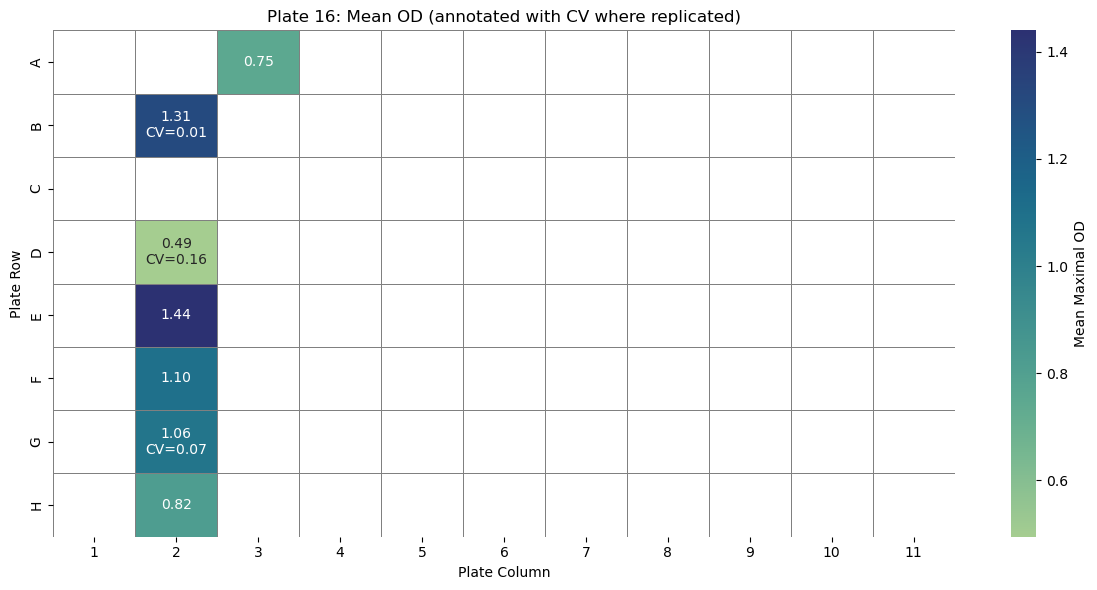

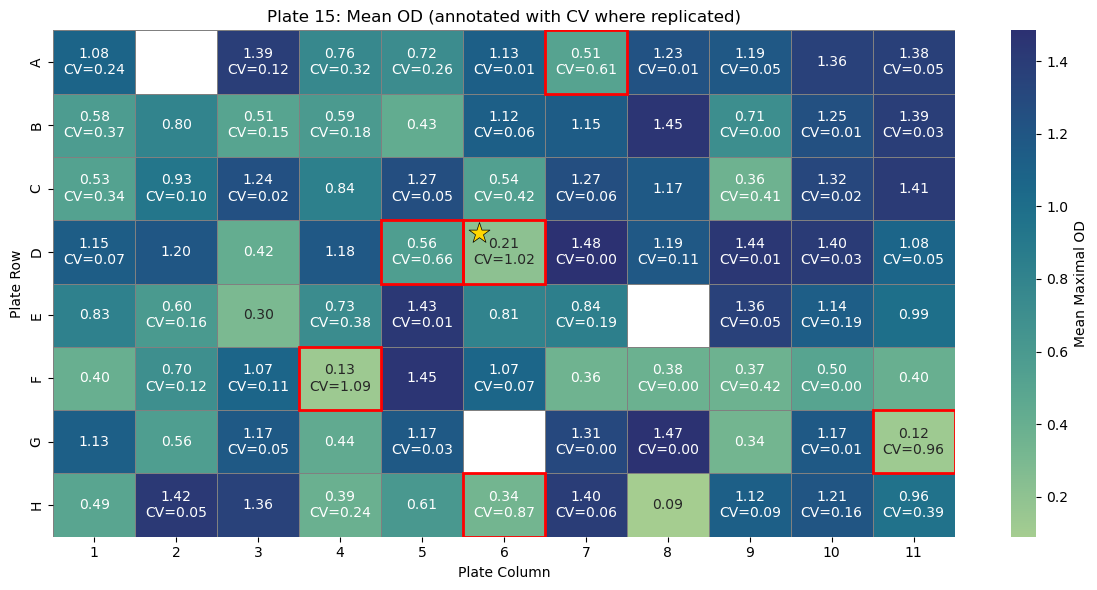

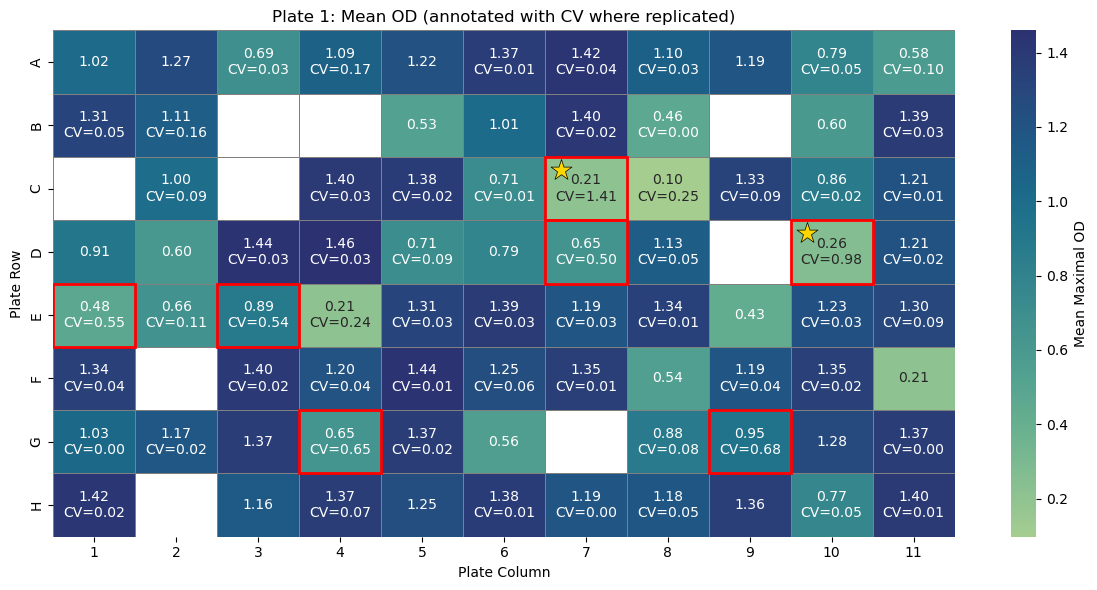

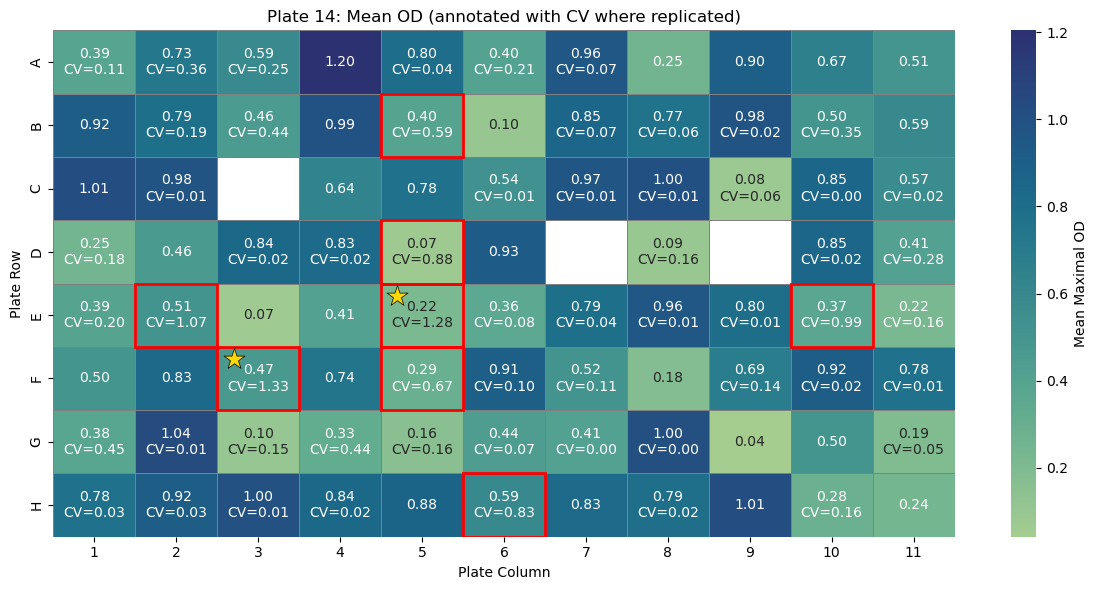

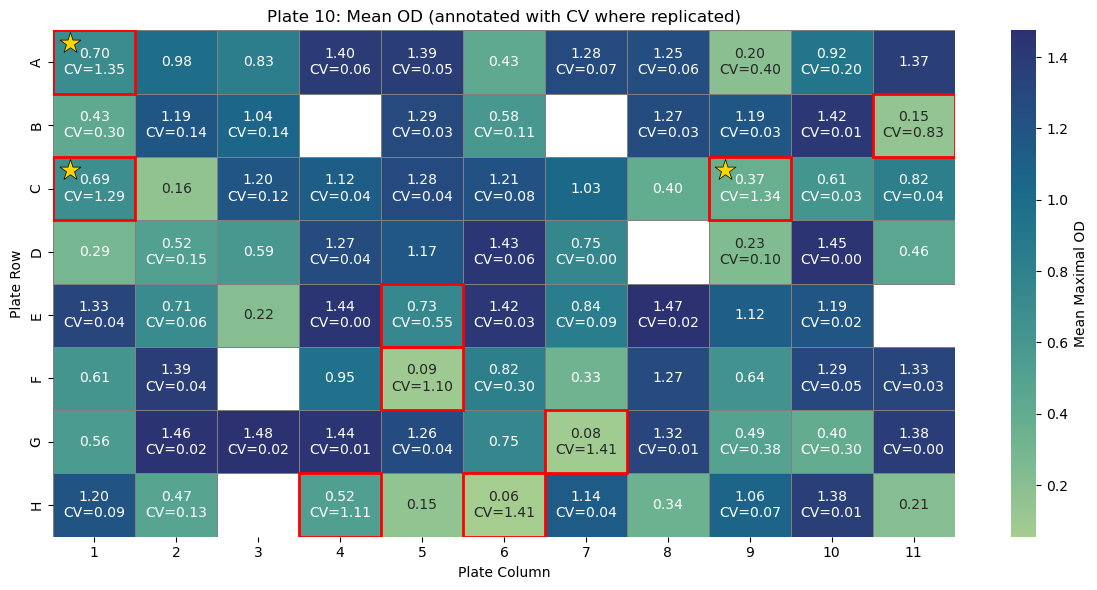

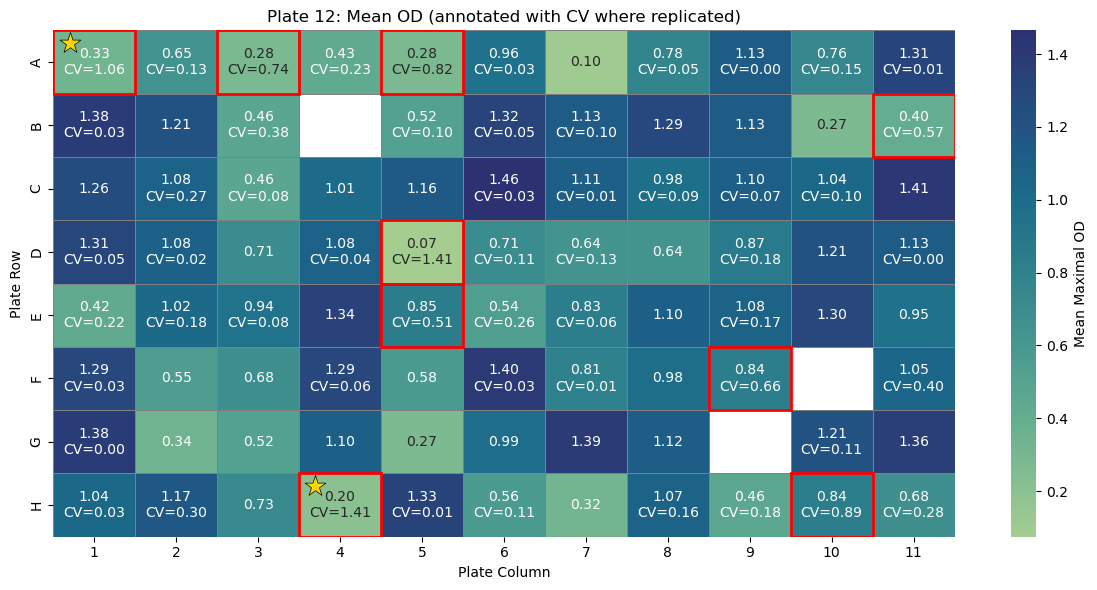

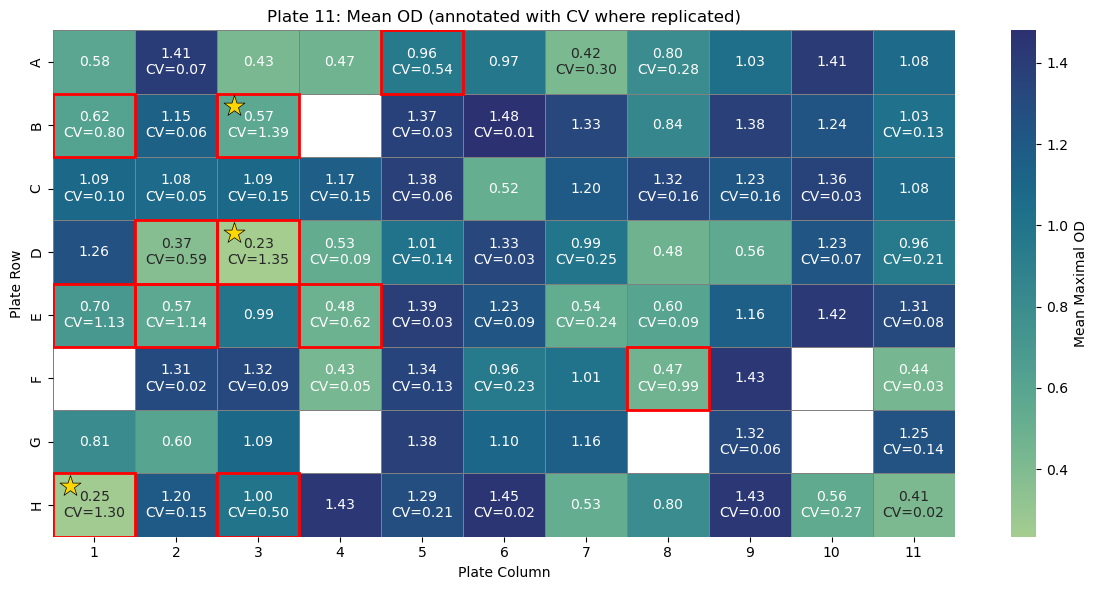

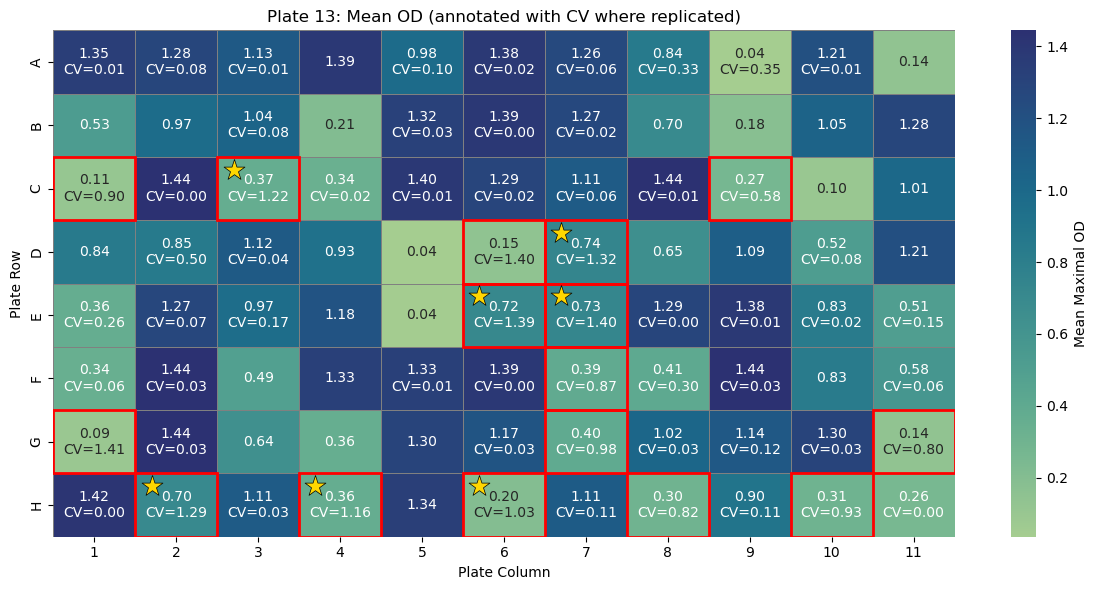

In [126]:
# Plate Number
# 1     0.116667
# 10    0.152542
# 11    0.215686
# 12    0.163636
# 13    0.258065
# 14    0.135593
# 15    0.103448
# 16    0.000000

# lowest to highest cv order
plot_plate_heatmap(16)
plot_plate_heatmap(15)
plot_plate_heatmap(1)
plot_plate_heatmap(14)
plot_plate_heatmap(10)
plot_plate_heatmap(12)
plot_plate_heatmap(11)red
plot_plate_heatmap(13)


## 3.4 Plate OD Distribution Summary & Boxplot

In [45]:
df.groupby('Plate Number')['Maximal OD'].describe()

,count,mean,std,min,25%,50%,75%,max
Plate Number,,,,,,,,
1,139.0,1.050773,0.379547,0.000,0.7750,1.200000,1.360000,1.490
10,141.0,0.925527,0.465649,0.000,0.5400,1.110000,1.320000,1.500
11,133.0,0.974184,0.404406,0.010,0.6000,1.100000,1.328606,1.490
12,140.0,0.886435,0.382743,0.000,0.5750,0.955000,1.210000,1.500
13,150.0,0.857141,0.494357,0.000,0.3650,1.040000,1.310000,1.480
14,144.0,0.604090,0.314310,0.021,0.3360,0.635734,0.880250,1.204
15,143.0,0.923687,0.413304,0.030,0.5400,1.050000,1.270000,1.500
16,10.0,0.985000,0.336526,0.440,0.7675,1.055000,1.255000,1.440


<Axes: title={'center': 'Maximal OD'}, xlabel='Plate Number'>

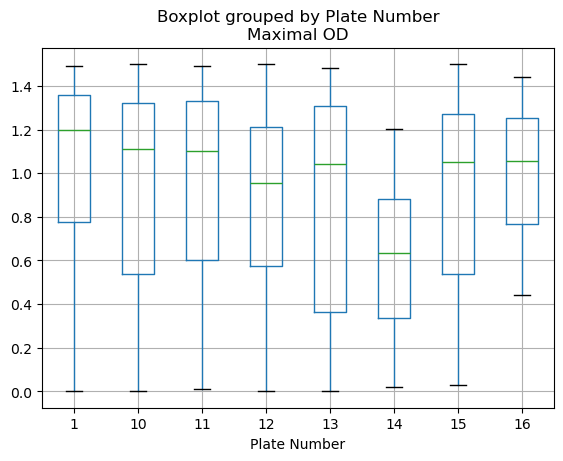

In [46]:
df.boxplot(column='Maximal OD', by='Plate Number')

# Final DF and well QC Classification

In [61]:
import numpy as np
import pandas as pd


MEDIA_COLS = [
    "K2HPO4: Dipotassium phosphate",
    "Peptone (Soy)",
    "Glucose",
    "Ammonium citrate",
    "MgSO4: Magnesium sulfate",
    "Yeast extract",
    "MnSO4 · H2O: Manganese sulfate",
    "Meat extract",
    "CH3COONa: Sodium acetate",
    "Tween 80 [ml/L]",
]

KEY_COLS = ["Plate Number", "Plate Row", "Plate Column"] + MEDIA_COLS

# check dtypes
df = df.copy()
df["Plate Column"] = df["Plate Column"].astype(int)
df["Plate Row"] = df["Plate Row"].astype(str)

# growth threshold 5th percentile, if the well is in this percentile then they are true growth. 
growth_threshold = float(df["Maximal OD"].quantile(0.05))
print("Growth threshold (5th percentile):", growth_threshold)

# Aggregate to one row per condition, joins replicates.
agg = (
    df.groupby(KEY_COLS)["Maximal OD"]
      .agg(
          n="count",
          od_min="min",
          od_max="max",
          mean_od="mean",
          median_od="median",
          std_od="std",
      )
      .reset_index()
)

# CV only meaningful if n>=2 (replicates) and mean>0 (measures observed)
agg["cv"] = agg["std_od"] / agg["mean_od"]
agg.loc[(agg["n"] < 2) | (agg["mean_od"] <= 0), "cv"] = np.nan

# replicate flag
agg["replicate_flag"] = (agg["n"] >= 2).astype(int)

#  if a well is has a replicate measurement then i want to add both OD to the agg df... how to pull this off...
# sort by the coulmuns in key_cols, you end up with the larger of the od replicate mesurements on top. 
df_sorted = df.sort_values(KEY_COLS + ["ID"]).copy()

# rank replicate within group, the larger one gets a 1 and the smaller one a 2. 
df_sorted["rep_rank"] = df_sorted.groupby(KEY_COLS).cumcount() + 1

# pivot
od_wide = (
    df_sorted.pivot_table(
        index=KEY_COLS,
        columns="rep_rank",
        values="Maximal OD",
        aggfunc="first"
    )
    .reset_index()
)

# rename first two revealingly (if more than 2 exist, they’ll appear as extra columns)
rename_map = {}
if 1 in od_wide.columns: rename_map[1] = "maximal_od1"
if 2 in od_wide.columns: rename_map[2] = "maximal_od2"
od_wide = od_wide.rename(columns=rename_map)

# merge
qc_df = agg.merge(od_wide, on=KEY_COLS, how="left")

# For singles, keep maximal_od1 equal to the observed OD (mean_od == single OD)
qc_df["maximal_od1"] = qc_df["maximal_od1"].fillna(qc_df["mean_od"])

# Declare Flags: above threshold (5th percentile) + binary disagreement 
qc_df["above_growth_threshold"] = (qc_df["median_od"] > growth_threshold)

# Binary disagreement: one <= threshold and one > threshold (only if replicated)
qc_df["binary_disagreement"] = (
    (qc_df["replicate_flag"] == 1) &
    (qc_df["od_min"] <= growth_threshold) &
    (qc_df["od_max"] > growth_threshold)
)

# Classification: top candidate / rerun / true no growth
# define "true no growth" as BOTH replicates <= threshold, or single <= threshold
qc_df["true_no_growth"] = (
    ((qc_df["replicate_flag"] == 0) & (qc_df["median_od"] <= growth_threshold)) |
    ((qc_df["replicate_flag"] == 1) & (qc_df["od_max"] <= growth_threshold))
)

# define rerun: replicated and unstable (high CV or binary disagreement)
qc_df["rerun"] = (
    (qc_df["replicate_flag"] == 1) &
    (qc_df["binary_disagreement"] | (qc_df["cv"] > 0.5))
)

# top candidate: above threshold AND not rerun AND not true-no-growth
qc_df["top_candidate"] = (
    (qc_df["median_od"] > growth_threshold) &
    (~qc_df["rerun"]) &
    (~qc_df["true_no_growth"])
)

def classify_row(r):
    if r["top_candidate"]:
        return "top_candidate"
    if r["rerun"]:
        return "rerun"
    if r["true_no_growth"]:
        return "true_no_growth"
    return "other"  # e.g., single above threshold but not top? usually won’t happen with these rules

qc_df["final_class"] = qc_df.apply(classify_row, axis=1)

# keep only requested columns in a tidy order 
keep_cols = (
    KEY_COLS +
    ["n", "replicate_flag", "maximal_od1", "maximal_od2",
     "mean_od", "median_od", "std_od", "cv",
     "binary_disagreement", "above_growth_threshold",
     "final_class"]
)

qc_df_final = qc_df[keep_cols].copy()


Growth threshold (5th percentile): 0.11089076949500001


great now we have a df that has all the info found and final decisions:
* the well location(plate, row, col)
* media components
* number of replicates (n) and replicate flag
* the two ODs, mean od, median OD, std, cv
* binary dissagreement flag,
* above growth threshold flag
* final classification
* :)

In [41]:
qc_df_final.head()

,Plate Number,Plate Row,Plate Column,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,...,replicate_flag,maximal_od1,maximal_od2,mean_od,median_od,std_od,cv,binary_disagreement,above_growth_threshold,final_class
0,1,A,1,1,10,10,1,0.1,5,0.1,...,0,1.02,NaN,1.020,1.020,NaN,NaN,False,True,top_candidate
1,1,A,2,1,0,40,10,0.1,10,0.2,...,0,1.27,NaN,1.270,1.270,NaN,NaN,False,True,top_candidate
2,1,A,3,1,5,10,0,0.1,40,1.0,...,1,0.70,0.67,0.685,0.685,0.021213,0.030968,False,True,top_candidate
3,1,A,4,1,10,40,0,0.2,20,0.0,...,1,0.96,1.23,1.095,1.095,0.190919,0.174355,False,True,top_candidate
4,1,A,5,1,20,50,4,2.0,0,0.1,...,0,1.22,NaN,1.220,1.220,NaN,NaN,False,True,top_candidate


## Pie chart of sample classification

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

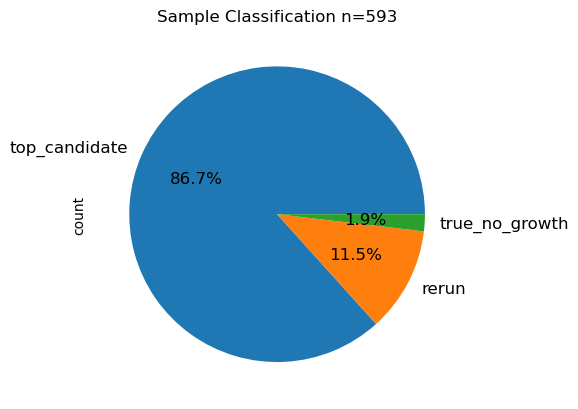

In [63]:
qc_df_final["final_class"].value_counts().plot.pie(title=f"Sample Classification n={qc_df_final.shape[0]}",autopct='%1.1f%%', fontsize=12)
plt.show()


# Analysis

## Plate completness

In [67]:
plate_completeness = (
    qc_df
    .groupby("Plate Number")[["Plate Row","Plate Column"]]
    .apply(lambda x: x.drop_duplicates().shape[0])
    .reset_index(name="unique_well_positions")
)

plate_completeness["percent_complete"] = (
    plate_completeness["unique_well_positions"] / 88 * 100
)

plate_completeness


,Plate Number,unique_well_positions,percent_complete
0,1,79,89.772727
1,10,82,93.181818
2,11,82,93.181818
3,12,85,96.590909
4,13,88,100.000000
5,14,85,96.590909
6,15,85,96.590909
7,16,7,7.954545


## Edge Effect

In [64]:
# start from aggregated well_stats (one row per well position)
plate_wells = qc_df.copy()

plate_wells["is_edge"] = (
    (plate_wells["Plate Row"].isin(["A","H"])) |
    (plate_wells["Plate Column"].isin([1,11]))
)

edge_test = (
    plate_wells
    .groupby(["Plate Number","is_edge"])["median_od"]
    .median()
    .reset_index()
)

edge_test


,Plate Number,is_edge,median_od
0,1,False,1.115000
1,1,True,1.212500
2,10,False,1.122500
3,10,True,0.762500
4,11,False,1.145000
5,11,True,0.970000
6,12,False,1.010000
7,12,True,0.892500
8,13,False,0.995000
9,13,True,0.842500


In [65]:
edge_pivot = edge_test.pivot(
    index="Plate Number",
    columns="is_edge",
    values="median_od"
)

edge_pivot["edge_minus_interior"] = edge_pivot[True] - edge_pivot[False]

edge_pivot


is_edge,False,True,edge_minus_interior
Plate Number,,,
1,1.1150,1.212500,0.097500
10,1.1225,0.762500,-0.360000
11,1.1450,0.970000,-0.175000
12,1.0100,0.892500,-0.117500
13,0.9950,0.842500,-0.152500
14,0.5355,0.630105,0.094605
15,0.9975,1.075000,0.077500
16,1.1000,0.785000,-0.315000


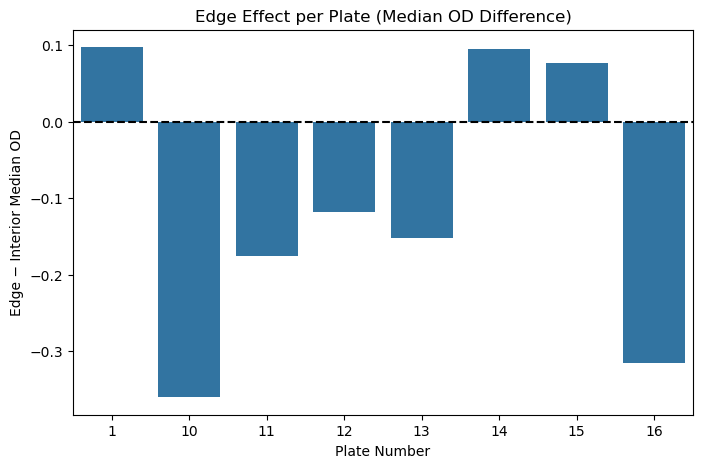

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

edge_pivot_reset = edge_pivot.reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=edge_pivot_reset,
    x="Plate Number",
    y="edge_minus_interior"
)

plt.axhline(0, color="black", linestyle="--")
plt.title("Edge Effect per Plate (Median OD Difference)")
plt.ylabel("Edge − Interior Median OD")
plt.show()


In [82]:
edge_pivot

is_edge,False,True,edge_minus_interior,edge_effect_scaled
Plate Number,,,,
1,1.1150,1.212500,0.097500,0.159836
10,1.1225,0.762500,-0.360000,-0.459330
11,1.1450,0.970000,-0.175000,-0.241639
12,1.0100,0.892500,-0.117500,-0.202586
13,0.9950,0.842500,-0.152500,-0.170255
14,0.5355,0.630105,0.094605,0.203233
15,0.9975,1.075000,0.077500,0.108392
16,1.1000,0.785000,-0.315000,-0.750000


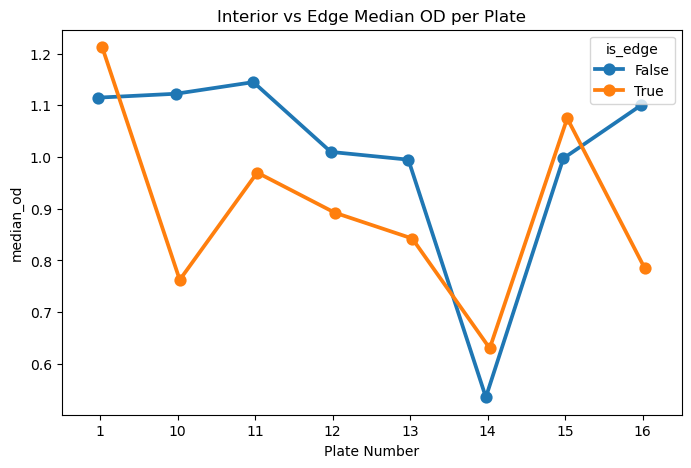

In [83]:
plt.figure(figsize=(8,5))
sns.pointplot(
    data=edge_test,
    x="Plate Number",
    y="median_od",
    hue="is_edge",
    dodge=True
)
plt.title("Interior vs Edge Median OD per Plate")
plt.show()


## Plate shift

In [64]:
# lets see the the difference of median OD of each plate to the global OD

plate_medians = qc_df_final.groupby("Plate Number")["median_od"].median()
global_median = qc_df_final["median_od"].median()

plate_shift = plate_medians - global_median

print("Plate medians:\n", plate_medians)
print("\nGlobal median:", global_median)
print("\nPlate shift:\n", plate_shift)


Plate medians:
 Plate Number
1     1.1850
10    0.9650
11    1.0800
12    0.9800
13    0.9475
14    0.5950
15    1.0700
16    1.0650
Name: median_od, dtype: float64

Global median: 0.95

Plate shift:
 Plate Number
1     0.2350
10    0.0150
11    0.1300
12    0.0300
13   -0.0025
14   -0.3550
15    0.1200
16    0.1150
Name: median_od, dtype: float64


## Bar Plot

In [76]:
df = pd.read_csv("C:/Users/dlmat/Documents/Projects/Differencial_Bio/data/EDA_OD600/sanity_check.csv")

In [77]:
global_median = df["Maximal OD"].median()

plate_summary = (
    df.groupby("Plate Number")["Maximal OD"]
      .median()
      .reset_index(name="plate_median")
)

plate_summary["shift_from_global"] = plate_summary["plate_median"] - global_median


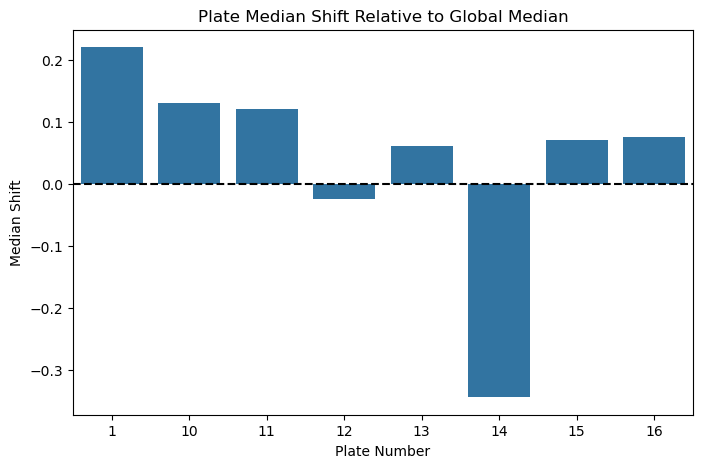

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(
    data=plate_summary,
    x="Plate Number",
    y="shift_from_global"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Plate Median Shift Relative to Global Median")
plt.ylabel("Median Shift")
plt.show()


### Normalize for plate shifting

In [65]:
# Median-centering normalization, as some rows show to be shifted (keep raw too)
qc_df_final = qc_df_final.copy()
qc_df_final["plate_median"] = qc_df_final["Plate Number"].map(plate_medians)
qc_df_final["median_od_norm"] = qc_df_final["median_od"] - qc_df_final["plate_median"] + global_median


In [66]:
qc_df_final.groupby("Plate Number")["median_od_norm"].median()

Plate Number
1     0.95
10    0.95
11    0.95
12    0.95
13    0.95
14    0.95
15    0.95
16    0.95
Name: median_od_norm, dtype: float64

<Axes: title={'center': 'median_od_norm'}, xlabel='Plate Number'>

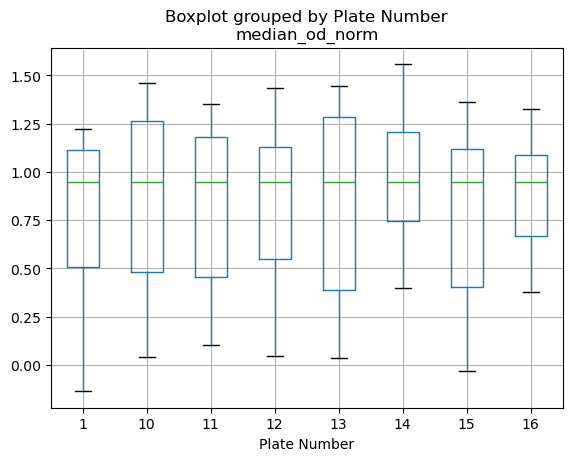

In [67]:
qc_df_final.boxplot(column='median_od_norm', by='Plate Number')

In [75]:
output_path = "C:/Users/dlmat/Documents/Projects/Differencial_Bio/data/EDA_OD600"
qc_df_final.to_csv(output_path+'/norm_df_final.csv')

    

In [76]:
qc_df_final.head()

,Plate Number,Plate Row,Plate Column,K2HPO4: Dipotassium phosphate,Peptone (Soy),Glucose,Ammonium citrate,MgSO4: Magnesium sulfate,Yeast extract,MnSO4 · H2O: Manganese sulfate,...,maximal_od2,mean_od,median_od,std_od,cv,binary_disagreement,above_growth_threshold,final_class,plate_median,median_od_norm
0,1,A,1,1,10,10,1,0.1,5,0.1,...,NaN,1.020,1.020,NaN,NaN,False,True,top_candidate,1.185,0.785
1,1,A,2,1,0,40,10,0.1,10,0.2,...,NaN,1.270,1.270,NaN,NaN,False,True,top_candidate,1.185,1.035
2,1,A,3,1,5,10,0,0.1,40,1.0,...,0.67,0.685,0.685,0.021213,0.030968,False,True,top_candidate,1.185,0.450
3,1,A,4,1,10,40,0,0.2,20,0.0,...,1.23,1.095,1.095,0.190919,0.174355,False,True,top_candidate,1.185,0.860
4,1,A,5,1,20,50,4,2.0,0,0.1,...,NaN,1.220,1.220,NaN,NaN,False,True,top_candidate,1.185,0.985


## Replicate Agreement Plots

In [70]:
df = pd.read_csv("C:/Users/dlmat/Documents/Projects/Differencial_Bio/data/EDA_OD600/norm_df_final.csv")

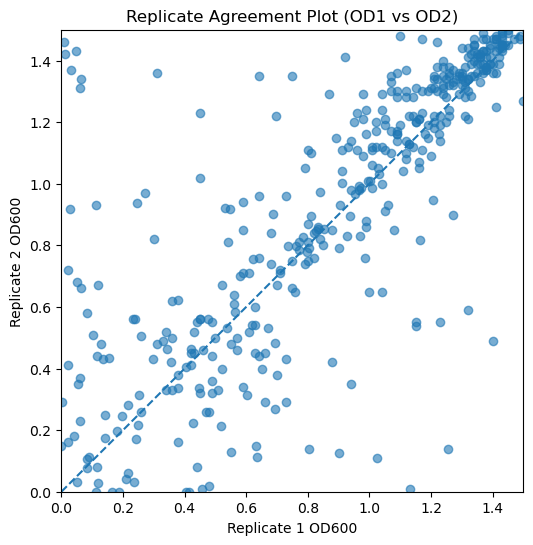

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Keep only replicate rows
rep_df = df[df["replicate_flag"] == 1].copy()

x = rep_df["maximal_od1"]
y = rep_df["maximal_od2"]

plt.figure(figsize=(6,6))

# Scatter
plt.scatter(x, y, alpha=0.6)

# Add y=x line
lims = [
    min(x.min(), y.min()),
    max(x.max(), y.max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Replicate 1 OD600")
plt.ylabel("Replicate 2 OD600")
plt.title("Replicate Agreement Plot (OD1 vs OD2)")

plt.gca().set_aspect("equal", adjustable="box")

plt.show()


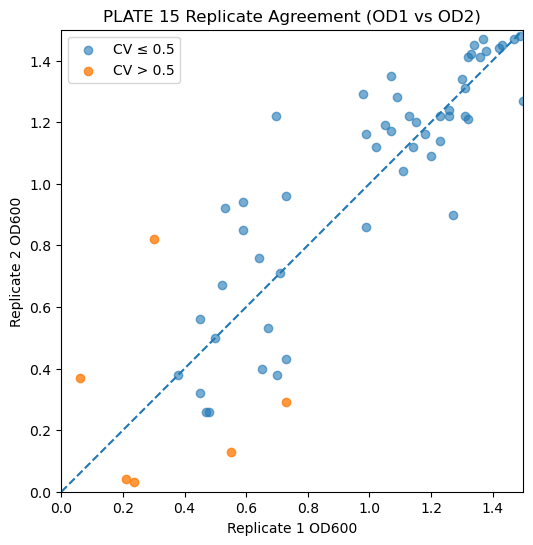

In [75]:
plt.figure(figsize=(6,6))
selected_df = rep_df[rep_df['Plate Number']==15]

# Normal replicates
good = selected_df["cv"] <= 0.5
plt.scatter(
    selected_df.loc[good, "maximal_od1"],
    selected_df.loc[good, "maximal_od2"],
    alpha=0.6,
    label="CV ≤ 0.5"
)

# High CV replicates
bad = selected_df["cv"] > 0.5
plt.scatter(
    selected_df.loc[bad, "maximal_od1"],
    selected_df.loc[bad, "maximal_od2"],
    alpha=0.8,
    label="CV > 0.5"
)

# y=x reference line
lims = [
    min(x.min(), y.min()),
    max(x.max(), y.max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Replicate 1 OD600")
plt.ylabel("Replicate 2 OD600")
plt.title("PLATE 15 Replicate Agreement (OD1 vs OD2)")
plt.legend()

plt.gca().set_aspect("equal", adjustable="box")

plt.show()


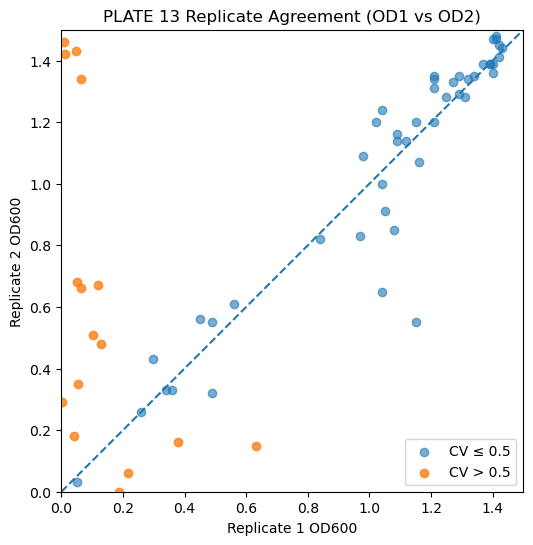

In [74]:
plt.figure(figsize=(6,6))
selected_df = rep_df[rep_df['Plate Number']==13]

# Normal replicates
good = selected_df["cv"] <= 0.5
plt.scatter(
    selected_df.loc[good, "maximal_od1"],
    selected_df.loc[good, "maximal_od2"],
    alpha=0.6,
    label="CV ≤ 0.5"
)

# High CV replicates
bad = selected_df["cv"] > 0.5
plt.scatter(
    selected_df.loc[bad, "maximal_od1"],
    selected_df.loc[bad, "maximal_od2"],
    alpha=0.8,
    label="CV > 0.5"
)

# y=x reference line
lims = [
    min(x.min(), y.min()),
    max(x.max(), y.max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Replicate 1 OD600")
plt.ylabel("Replicate 2 OD600")
plt.title("PLATE 13 Replicate Agreement (OD1 vs OD2)")
plt.legend()

plt.gca().set_aspect("equal", adjustable="box")

plt.show()
